# CatboostDifference

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

In [2]:
path_samples = 'data/test_sample_data.csv'
path_ridge_model= 'data/ridge_model_smote.pkl'


In [3]:
sample_data = pd.read_csv(path_samples )

In [15]:
sample_data

,Age,Status,Experiment,Sample,Sex,CatboostP,RidgeP,Diff
0,24.0,Healthy,GSE157585,SRR12604218,0,23.221191,29.056820,-0.778809
1,18.0,Healthy,GSE167186,SRR13759023,0,26.198732,24.422029,8.198732
2,23.0,Healthy,GSE167186,SRR13759025,0,24.289711,20.977246,1.289711
3,26.4,untrained,GSE60590,SRR1555206,female,43.500786,41.666606,17.100786
4,71.0,Healthy,GSE157585,SRR12604184,0,68.304524,77.621266,-2.695476
...,...,...,...,...,...,...,...,...
103,71.0,Healthy,GSE157585,SRR12604112,0,70.909594,71.858171,-0.090406
104,23.0,Healthy,GSE167186,SRR13759011,0,25.604365,26.527594,2.604365
105,72.0,Healthy,GSE164471,SRR13388749,male,74.574402,49.635809,2.574402
106,71.0,Healthy,GSE157585,SRR12604127,0,67.757675,64.093399,-3.242325


In [6]:
sample_data['Status'].unique()

array(['Healthy', 'untrained', 'trained', 'Sarcopenia'], dtype=object)

In [17]:
sample_no_sarcopenia = sample_data[sample_data['Status']!='Sarcopenia']
sample_no_sarcopenia

,Age,Status,Experiment,Sample,Sex,CatboostP,RidgeP,Diff,Difference
0,24.0,Healthy,GSE157585,SRR12604218,0,23.221191,29.056820,-0.778809,-0.778809
1,18.0,Healthy,GSE167186,SRR13759023,0,26.198732,24.422029,8.198732,8.198732
2,23.0,Healthy,GSE167186,SRR13759025,0,24.289711,20.977246,1.289711,1.289711
3,26.4,untrained,GSE60590,SRR1555206,female,43.500786,41.666606,17.100786,17.100786
4,71.0,Healthy,GSE157585,SRR12604184,0,68.304524,77.621266,-2.695476,-2.695476
...,...,...,...,...,...,...,...,...,...
103,71.0,Healthy,GSE157585,SRR12604112,0,70.909594,71.858171,-0.090406,-0.090406
104,23.0,Healthy,GSE167186,SRR13759011,0,25.604365,26.527594,2.604365,2.604365
105,72.0,Healthy,GSE164471,SRR13388749,male,74.574402,49.635809,2.574402,2.574402
106,71.0,Healthy,GSE157585,SRR12604127,0,67.757675,64.093399,-3.242325,-3.242325


In [16]:
sample_data['Difference'] = sample_data['CatboostP'] - sample_data['Age']


In [20]:
sample_no_sarcopenia['Status'] = sample_no_sarcopenia['Status'].replace('untrained', 'Sedentary')
sample_no_sarcopenia

/tmp/ipykernel_18746/23422420.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_no_sarcopenia['Status'] = sample_no_sarcopenia['Status'].replace('untrained', 'Sedentary')


,Age,Status,Experiment,Sample,Sex,CatboostP,RidgeP,Diff,Difference
0,24.0,Healthy,GSE157585,SRR12604218,0,23.221191,29.056820,-0.778809,-0.778809
1,18.0,Healthy,GSE167186,SRR13759023,0,26.198732,24.422029,8.198732,8.198732
2,23.0,Healthy,GSE167186,SRR13759025,0,24.289711,20.977246,1.289711,1.289711
3,26.4,Sedentary,GSE60590,SRR1555206,female,43.500786,41.666606,17.100786,17.100786
4,71.0,Healthy,GSE157585,SRR12604184,0,68.304524,77.621266,-2.695476,-2.695476
...,...,...,...,...,...,...,...,...,...
103,71.0,Healthy,GSE157585,SRR12604112,0,70.909594,71.858171,-0.090406,-0.090406
104,23.0,Healthy,GSE167186,SRR13759011,0,25.604365,26.527594,2.604365,2.604365
105,72.0,Healthy,GSE164471,SRR13388749,male,74.574402,49.635809,2.574402,2.574402
106,71.0,Healthy,GSE157585,SRR12604127,0,67.757675,64.093399,-3.242325,-3.242325


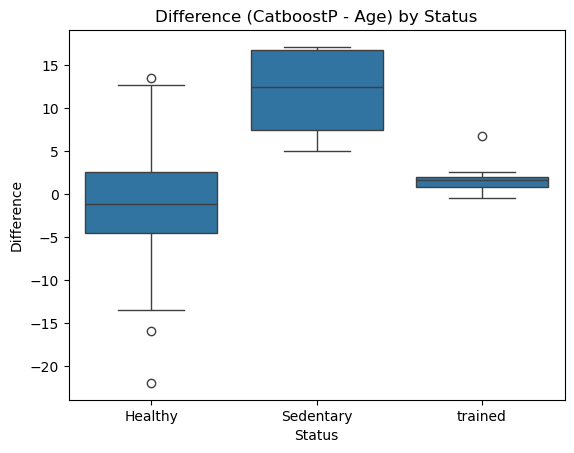

In [22]:

sns.boxplot(data=sample_no_sarcopenia, x='Status', y='Difference')
plt.title("Difference (CatboostP - Age) by Status")
plt.savefig("Figures/Difference_status.jpg")
plt.show()

In [7]:
group1 = sample_data[sample_data['Status'] == 'Healthy']['Diff']
group2 = sample_data[sample_data['Status'] == 'Sarcopenia']['Diff']

t_stat, p_val = ttest_ind(group1, group2, equal_var=False)
print(f"T-test: t={t_stat:.3f}, p={p_val:.3e}")

T-test: t=1.000, p=3.482e-01


In [8]:
diff_mean1 = group1.mean()
diff_mean2 = group2.mean()
mean_difference = diff_mean2 - diff_mean1  # Group2 - Group1
print(f"Mean difference: {mean_difference}")

Mean difference: -3.4360490510152157


In [9]:


group1 = sample_data[sample_data['Status'] == 'Healthy']['Diff']
group2 = sample_data[sample_data['Status'] == 'untrained']['Diff']

t_stat, p_val = ttest_ind(group1, group2, equal_var=False)
print(f"T-test: t={t_stat:.3f}, p={p_val:.3e}")

T-test: t=-4.124, p=2.109e-02


In [10]:
diff_mean1 = group1.mean()
diff_mean2 = group2.mean()
mean_difference = diff_mean2 - diff_mean1  # Group2 - Group1
print(f"Mean difference: {mean_difference}")

Mean difference: 12.82826119423716


In [11]:
group1 = sample_data[sample_data['Status'] == 'Healthy']['Diff']
group2 = sample_data[sample_data['Status'] == 'trained']['Diff']

t_stat, p_val = ttest_ind(group1, group2, equal_var=False)
print(f"T-test: t={t_stat:.3f}, p={p_val:.3e}")

T-test: t=-3.175, p=2.404e-03


In [12]:
diff_mean1 = group1.mean()
diff_mean2 = group2.mean()
mean_difference = diff_mean2 - diff_mean1  # Group2 - Group1
print(f"Mean difference: {mean_difference}")

Mean difference: 2.809749471775359


In [25]:
group1 = sample_data[sample_data['Status'] == 'trained']['Diff']
group2 = sample_data[sample_data['Status'] == 'untrained']['Diff']

t_stat, p_val = ttest_ind(group1, group2, equal_var=False)
print(f"T-test: t={t_stat:.3f}, p={p_val:.3e}")

T-test: t=-3.254, p=4.330e-02


In [26]:
diff_mean1 = group1.mean()
diff_mean2 = group2.mean()
mean_difference = diff_mean2 - diff_mean1  # Group2 - Group1
print(f"Mean difference: {mean_difference}")

Mean difference: 10.0185117224618


In [13]:
GSE60590_metadata = pd.read_csv('data/GSE60590_metadata.csv')


In [14]:
filtered_metadata = GSE60590_metadata[GSE60590_metadata['Run'].isin(sample_data['Sample'])]


In [15]:
filtered_metadata[['BioSample','exercise_status', 'Experiment', 'gender', 'Age']]

,BioSample,exercise_status,Experiment,gender,Age
1,SAMN03000658,trained,SRX684330,female,26.4
7,SAMN03000663,trained,SRX684335,female,26.4
9,SAMN03000665,trained,SRX684337,male,27.5
10,SAMN03000665,trained,SRX684337,male,27.5
11,SAMN03000666,untrained,SRX684338,male,27.5
12,SAMN03000667,trained,SRX684339,male,27.5
13,SAMN03000668,trained,SRX684340,female,26.4
14,SAMN03000669,trained,SRX684341,male,27.5
16,SAMN03000670,untrained,SRX684342,female,26.4
24,SAMN03000677,trained,SRX684349,male,27.5


In [16]:
merged_data = sample_data.merge(filtered_metadata[['Run', 'exercise_status']], 
                                left_on='Sample', right_on='Run', how='inner')

# Now filter based on exercise_status
group1 = merged_data[merged_data['exercise_status'] == 'untrained']['Diff']
group2 = merged_data[merged_data['exercise_status'] == 'trained']['Diff']

t_stat, p_val = ttest_ind(group1, group2, equal_var=False)
print(f"T-test: t={t_stat:.3f}, p={p_val:.3e}")

T-test: t=3.254, p=4.330e-02


In [17]:
diff_mean1 = group1.mean()
diff_mean2 = group2.mean()
mean_difference = diff_mean2 - diff_mean1  # Group2 - Group1
print(f"Mean difference: {mean_difference}")

Mean difference: -10.0185117224618


In [18]:
merged_data.sort_values(by="Status")

,Age,Status,Experiment,Sample,Sex,CatboostP,RidgeP,Diff,Run,exercise_status
2,27.5,trained,GSE60590,SRR1555212,male,30.070739,30.694747,2.570739,SRR1555212,trained
3,27.5,trained,GSE60590,SRR1555193,male,28.448690,21.054081,0.948690,SRR1555193,trained
4,26.4,trained,GSE60590,SRR1555180,female,33.185480,34.154560,6.785480,SRR1555180,trained
5,26.4,trained,GSE60590,SRR1555205,female,28.028628,26.184954,1.628628,SRR1555205,trained
6,27.5,trained,GSE60590,SRR1555210,male,29.127282,38.152336,1.627282,SRR1555210,trained
9,27.5,trained,GSE60590,SRR1555188,male,29.855485,34.656939,2.355485,SRR1555188,trained
10,26.4,trained,GSE60590,SRR1555186,female,27.661871,30.028612,1.261871,SRR1555186,trained
11,27.5,trained,GSE60590,SRR1555213,male,27.042835,38.151542,-0.457165,SRR1555213,trained
12,27.5,trained,GSE60590,SRR1555191,male,29.322059,22.715334,1.822059,SRR1555191,trained
13,27.5,trained,GSE60590,SRR1555203,male,27.226685,29.718648,-0.273315,SRR1555203,trained


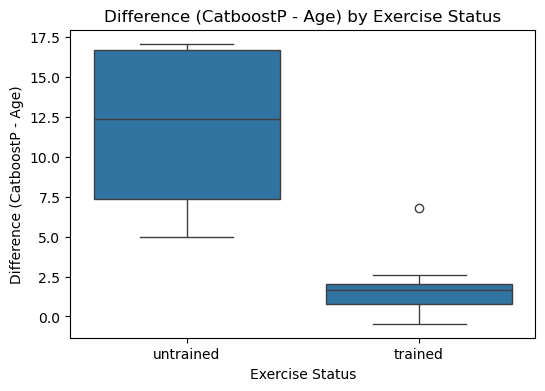

In [19]:


# Create the boxplot
plt.figure(figsize=(6, 4))
sns.boxplot(data=merged_data, x='exercise_status', y='Diff')

# Add title and labels
plt.title("Difference (CatboostP - Age) by Exercise Status")
plt.xlabel("Exercise Status")
plt.ylabel("Difference (CatboostP - Age)")

# Show the plot
plt.show()


In [20]:
repeated_biosamples = filtered_metadata[filtered_metadata.duplicated('BioSample', keep=False)]
repeated_biosamples.head()

,Run,Assay Type,AvgSpotLen,Bases,BioProject,biopsy_location,BioSample,Bytes,Center Name,Consent,...,Platform,ReleaseDate,create_date,version,Sample Name,source_name,SRA Study,Time_point,tissue,Age
9,SRR1555188,RNA-Seq,202,1186166018,PRJNA258599,right leg,SAMN03000665,757496699,GEO,public,...,ILLUMINA,2015-01-21T00:00:00Z,2014-08-21T10:10:00Z,1,GSM1482939,skeletal muscle,SRP045666,post-training period 1,skeletal muscle,27.5
10,SRR1555189,RNA-Seq,202,2315838696,PRJNA258599,right leg,SAMN03000665,1607267747,GEO,public,...,ILLUMINA,2015-07-22T00:00:00Z,2015-12-16T23:22:00Z,2,GSM1482939,skeletal muscle,SRP045666,post-training period 1,skeletal muscle,27.5


In [21]:
repeated_biosamples[['exercise_status', 'Experiment', 'gender', 'Age']]

,exercise_status,Experiment,gender,Age
9,trained,SRX684337,male,27.5
10,trained,SRX684337,male,27.5


In [22]:
repeated_biosamples_list = list(repeated_biosamples['Run'])

In [23]:
sample_data[sample_data['Sample'].isin(repeated_biosamples_list)]


,Age,Status,Experiment,Sample,Sex,CatboostP,RidgeP,Diff
69,27.5,trained,GSE60590,SRR1555188,male,29.855485,34.656939,2.355485
99,27.5,trained,GSE60590,SRR1555189,male,29.405290,38.214746,1.905290
